In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy

In [2]:
df = pd.read_csv('GGXY.csv')

#remove rows without data
df.replace('-',np.nan,inplace=True)
df.dropna(inplace=True)

X = df.drop(['Club','Carry'],axis=1).astype(float) #only keep key metrics
y = df['Carry'].astype(float)

### Random Forest

            Feature  Importance
1        Ball Speed    0.413385
0        Club Speed    0.396100
2      Launch Angle    0.109206
3         Spin Rate    0.059075
7      Attack Angle    0.006349
5      Face to Path    0.005014
4        Face Angle    0.004513
6         Club Path    0.003663
8  Launch Direction    0.002696


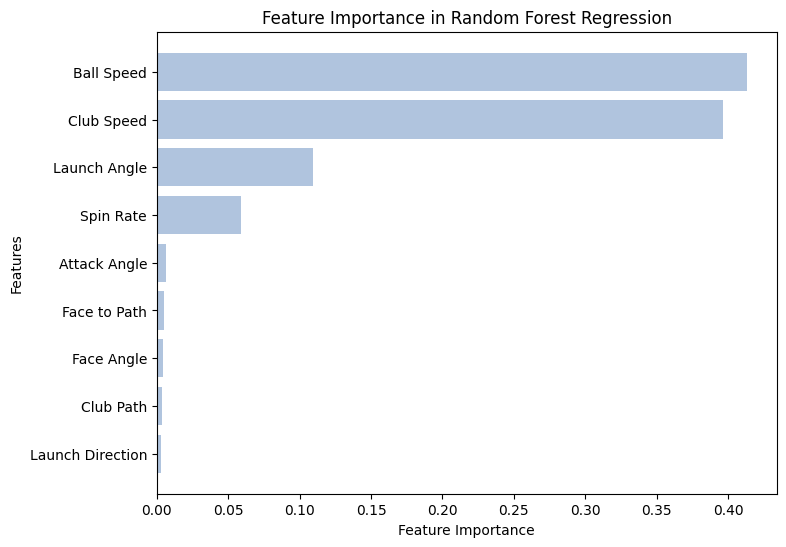

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

#train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=500)

#standard random forest regressor
rf_model = RandomForestRegressor(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

#importances
feature_importances = pd.DataFrame({'Feature': X.columns,'Importance': rf_model.feature_importances_}).sort_values(by='Importance', ascending=False)
print(feature_importances)

plt.figure(figsize=(8, 6))
plt.barh(feature_importances['Feature'], feature_importances['Importance'], color='lightsteelblue')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance in Random Forest Regression')
plt.gca().invert_yaxis()  # Invert y-axis for better readability
plt.savefig('RF.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

### SVR

R-squared for Club Speed: 0.76361
Adjusted Optimal X ranges for maximizing Y on Club Speed: [(99.89970941883767, 105.80970941883767)]


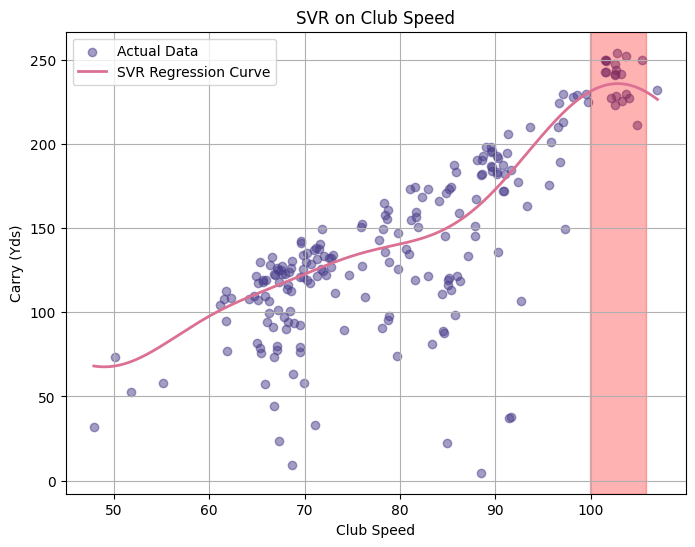

R-squared for Ball Speed: 0.92968
Adjusted Optimal X ranges for maximizing Y on Ball Speed: [(147.32817635270538, 155.6), (147.9654509018036, 155.6)]


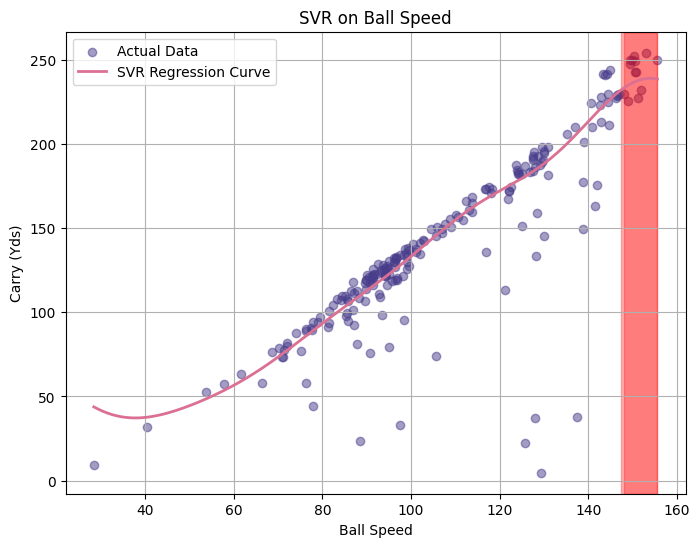

R-squared for Launch Angle: 0.10896
Adjusted Optimal X ranges for maximizing Y on Launch Angle: [(9.956182364729461, 14.126182364729463), (10.123316633266533, 14.293316633266535)]


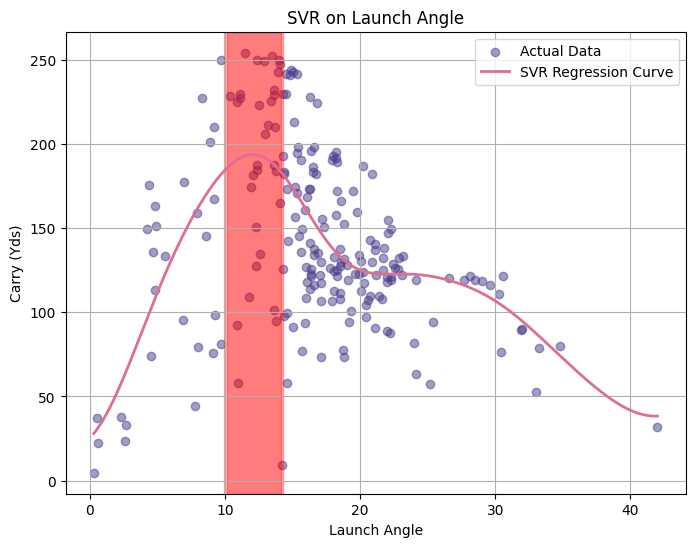

R-squared for Spin Rate: 0.01424
Adjusted Optimal X ranges for maximizing Y on Spin Rate: [(4484.554108216433, 5545.554108216433), (4505.816633266533, 5566.816633266533)]


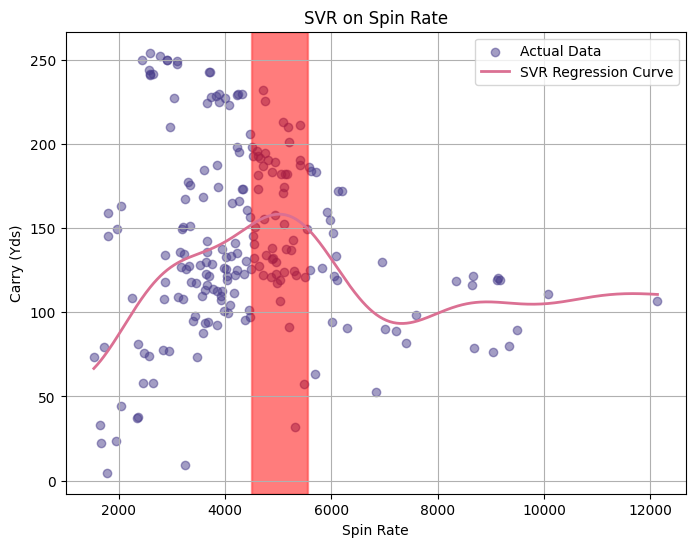

R-squared for Face Angle: 0.02175
Adjusted Optimal X ranges for maximizing Y on Face Angle: [(-4.7271242484969935, -0.9971242484969933), (-5.325120240480961, -1.5951202404809612)]


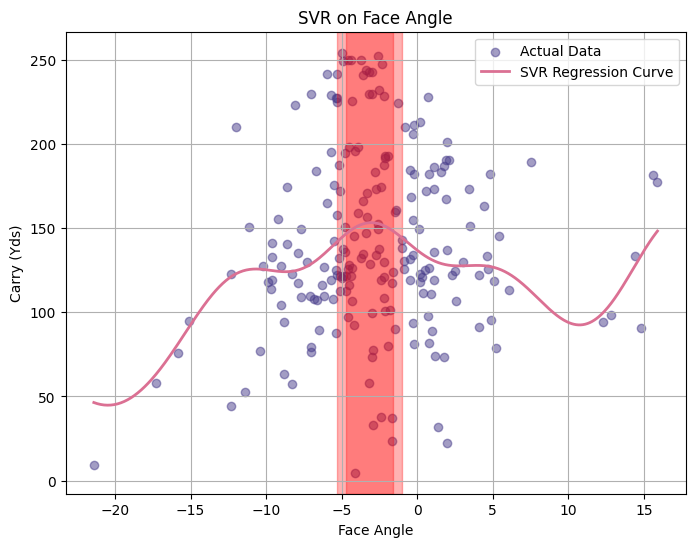

R-squared for Face to Path: 0.15649
Adjusted Optimal X ranges for maximizing Y on Face to Path: [(-0.06398797595190597, 2.6760120240480942)]


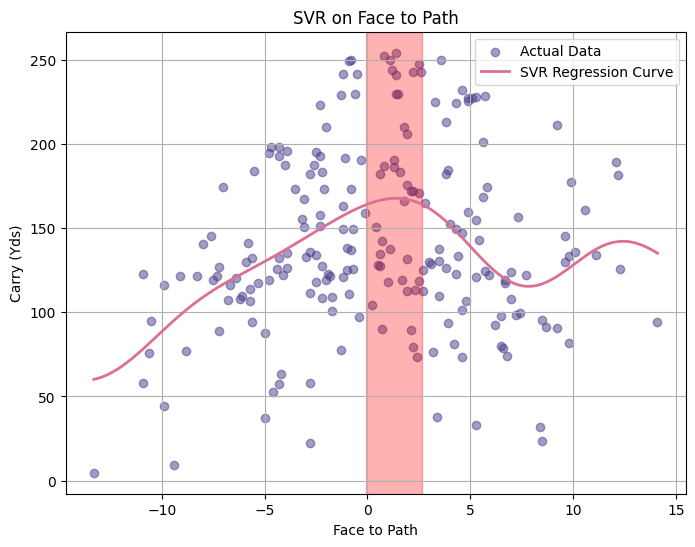

R-squared for Club Path: -0.06943
Adjusted Optimal X ranges for maximizing Y on Club Path: [(-7.275651302605212, -4.975651302605211), (-7.183466933867737, -4.883466933867736)]


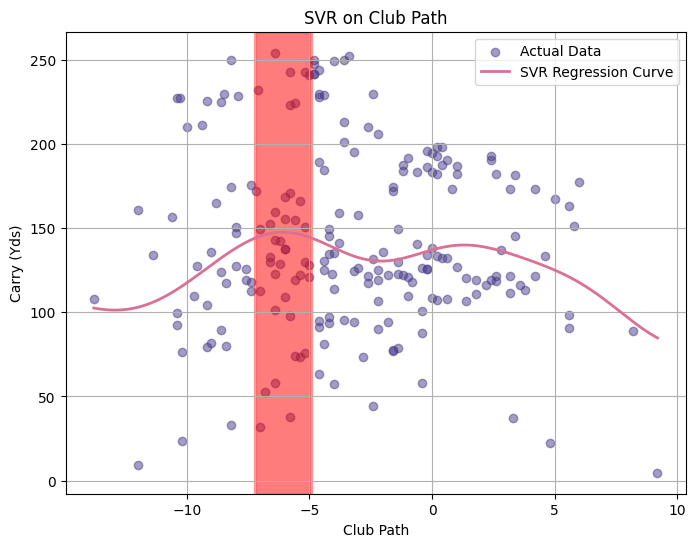

R-squared for Attack Angle: 0.09401
Adjusted Optimal X ranges for maximizing Y on Attack Angle: [(-2.2570741482965935, -0.4170741482965936)]


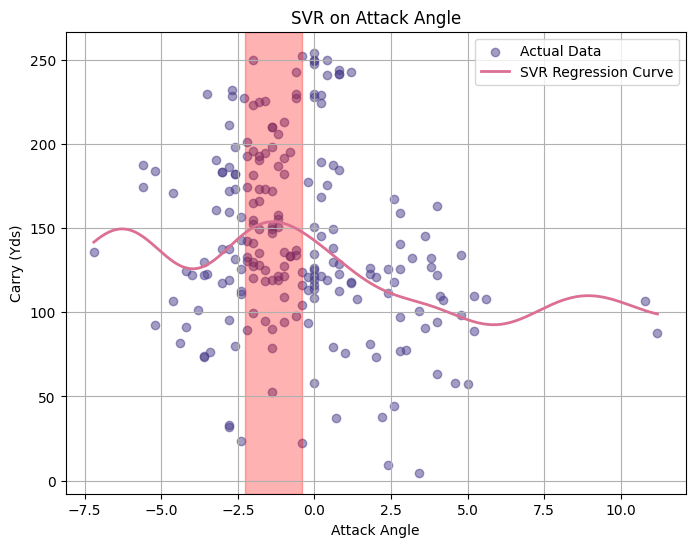

R-squared for Launch Direction: 0.01918
Adjusted Optimal X ranges for maximizing Y on Launch Direction: [(12.559999999999999, 14.1), (12.436553106212422, 14.1)]


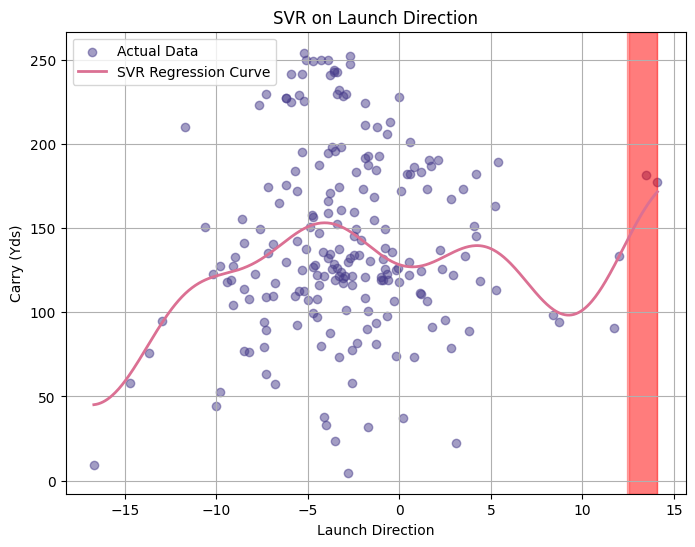

In [4]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

r2scores = []
optimal_ranges = []

for i in range(9):
    X_feature = X[X.columns[i]].to_numpy().reshape(-1, 1)
    X_train, X_test, y_train, y_test = train_test_split(X_feature, y, test_size=0.2, random_state=500)
    
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)

    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
    
    svr = SVR(kernel='rbf')
    svr.fit(X_train_scaled, y_train_scaled) 

    y_pred_scaled = svr.predict(X_test_scaled)
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
    
    X_range = np.linspace(X_feature.min(), X_feature.max(), 500).reshape(-1, 1)
    X_range_scaled = scaler_X.transform(X_range)
    
    y_range_pred_scaled = svr.predict(X_range_scaled)
    y_range_pred = scaler_y.inverse_transform(y_range_pred_scaled.reshape(-1, 1)).ravel()
    
    r2 = r2_score(y_test, y_pred)
    r2scores.append(r2)
    print(f'R-squared for {X.columns[i]}: {r2:.5f}')
    
    # Identify the optimal X range that maximizes Y
    max_y = np.max(y_range_pred) 
    threshold = (0.98) * max_y  # threshold for "near max" regions
    
    optimal_x_values = X_range[y_range_pred >= threshold].flatten()
    
    discrete_ranges = []
    start = optimal_x_values[0]
    
    for j in range(1, len(optimal_x_values)):
        if optimal_x_values[j] - optimal_x_values[j - 1] > (X_range[1] - X_range[0]):
            discrete_ranges.append((start, optimal_x_values[j - 1]))
            start = optimal_x_values[j] 
    discrete_ranges.append((start, optimal_x_values[-1])) 
    
    # Limit to at most 2 optimal ranges based on predicted Y value
    discrete_ranges = sorted(
        discrete_ranges, key=lambda r: np.mean(y_range_pred[(X_range.flatten() >= r[0]) & (X_range.flatten() <= r[1])]), reverse=True
    )[:2]
    
    fixed_width = 0.1 * (X_feature.max() - X_feature.min()) 
    
    adjusted_ranges = []
    for r in discrete_ranges:
        mid_point = (r[0] + r[1]) / 2 
        new_start = max(X_feature.min(), mid_point - fixed_width / 2)
        new_end = min(X_feature.max(), mid_point + fixed_width / 2)
        adjusted_ranges.append((new_start, new_end))
    
    optimal_ranges.append((X.columns[i], adjusted_ranges))
    
    print(f"Adjusted Optimal X ranges for maximizing Y on {X.columns[i]}: {adjusted_ranges}")
    
    plt.figure(figsize=(8, 6))
    plt.scatter(X_feature, y, color='darkslateblue', alpha=0.5, label='Actual Data')
    plt.plot(X_range, y_range_pred, color='palevioletred', lw=2, label='SVR Regression Curve')
    
    for r in adjusted_ranges:
        plt.axvspan(r[0], r[1], alpha=0.3, color='red')
    
    plt.xlabel(X.columns[i])
    plt.ylabel('Carry (Yds)')
    plt.title(f'SVR on {X.columns[i]}')
    plt.legend()
    plt.grid(True)
    plt.show()


### Finding Optimal Ranges

In [5]:
ranges_df = pd.DataFrame(optimal_ranges)
display(ranges_df.transpose())

,0,1,2,3,4,5,6,7,8
0,Club Speed,Ball Speed,Launch Angle,Spin Rate,Face Angle,Face to Path,Club Path,Attack Angle,Launch Direction
1,"[(99.89970941883767, 105.80970941883767)]","[(147.32817635270538, 155.6), (147.96545090180...","[(9.956182364729461, 14.126182364729463), (10....","[(4484.554108216433, 5545.554108216433), (4505...","[(-4.7271242484969935, -0.9971242484969933), (...","[(-0.06398797595190597, 2.6760120240480942)]","[(-7.275651302605212, -4.975651302605211), (-7...","[(-2.2570741482965935, -0.4170741482965936)]","[(12.559999999999999, 14.1), (12.4365531062124..."


### R-Squared

            Feature  R-squared
1        Ball Speed   0.929681
0        Club Speed   0.763610
5      Face to Path   0.156485
2      Launch Angle   0.108955
7      Attack Angle   0.094008
4        Face Angle   0.021751
8  Launch Direction   0.019185
3         Spin Rate   0.014243
6         Club Path  -0.069434


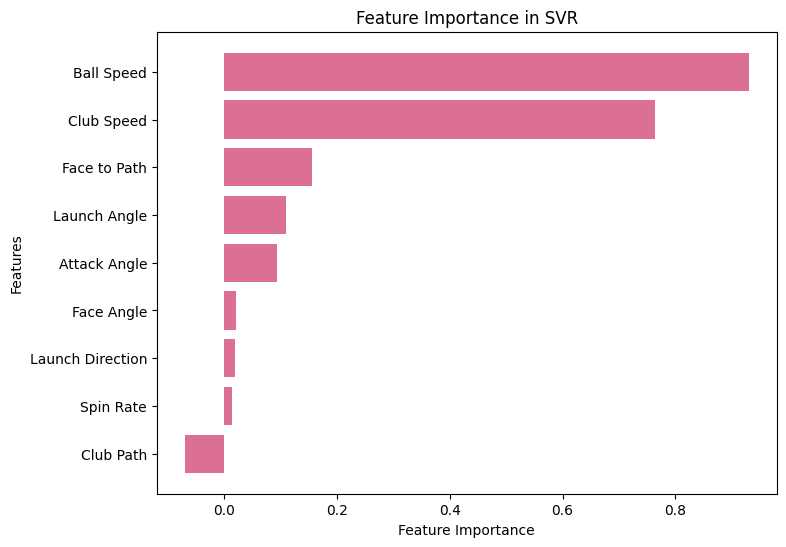

In [6]:
scores = pd.DataFrame({'Feature': X.columns,'R-squared': r2scores}).sort_values(by='R-squared', ascending=False)
print(scores)

plt.figure(figsize=(8, 6))
plt.barh(scores['Feature'], scores['R-squared'], color='palevioletred')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance in SVR')
plt.gca().invert_yaxis()  # Invert y-axis for better readability
plt.show()

### Heat maps

In [7]:
import scipy.ndimage
import scipy.interpolate

def create_heatmap(x, y, z, xlabel, ylabel, title):
    x = x.apply(pd.to_numeric, errors='coerce')
    y = y.apply(pd.to_numeric, errors='coerce')
    z = z.apply(pd.to_numeric, errors='coerce')

    heatmap_data, xedges, yedges = np.histogram2d(x, y, bins=100, weights=z)
    counts, _, _ = np.histogram2d(x, y, bins=100)
    
    heatmap_avg = np.divide(heatmap_data, counts, out=np.zeros_like(heatmap_data), where=counts != 0)
    
    x_centers = (xedges[:-1] + xedges[1:]) / 2
    y_centers = (yedges[:-1] + yedges[1:]) / 2
    X, Y = np.meshgrid(x_centers, y_centers, indexing='ij')

    mask = counts == 0
    known_x, known_y = X[~mask], Y[~mask]
    known_z = heatmap_avg[~mask]

    interp_func = scipy.interpolate.griddata(
        (known_x, known_y), known_z, (X, Y), method='linear', fill_value=0
    )
    
    heatmap_smooth = scipy.ndimage.gaussian_filter(interp_func, sigma=2.5)

    # Find optimal zones
    max_z = np.max(heatmap_smooth)
    threshold = 0.98 * max_z
    optimal_mask = heatmap_smooth >= threshold

    labeled, num_features = scipy.ndimage.label(optimal_mask)
    slices = scipy.ndimage.find_objects(labeled)

    # Extract at most 2 largest mean-z regions
    optimal_regions = []
    for sl in slices:
        region = heatmap_smooth[sl]
        region_mean = np.mean(region)
        optimal_regions.append((region_mean, sl))

    top_regions = sorted(optimal_regions, key=lambda x: x[0], reverse=True)[:2]

    print(f"Top Optimal Ranges for {xlabel} and {ylabel}:")
    for i, (_, sl) in enumerate(top_regions):
        x_range = (x_centers[sl[0].start], x_centers[sl[0].stop - 1])
        y_range = (y_centers[sl[1].start], y_centers[sl[1].stop - 1])
        #print(f"  Region {i + 1}: {xlabel} ∈ {x_range:.4f}, {ylabel} ∈ {y_range:.4f}")
        
    plt.figure(figsize=(10, 8))
    plt.imshow(
        heatmap_smooth.T, origin='lower', aspect='auto',
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        cmap='viridis', interpolation="bilinear"
    )
    cbar = plt.colorbar(label='Carry (yards)')
    cbar.set_label('Carry (yards)', fontsize=14)
    plt.xlabel(xlabel, fontsize=18)
    plt.ylabel(ylabel, fontsize=18)
    plt.title(title, fontsize=20)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.savefig('Heatmap.png', dpi=300, bbox_inches='tight', transparent=True)
    plt.show()


Top Optimal Ranges for Launch Angle and Face to Path:


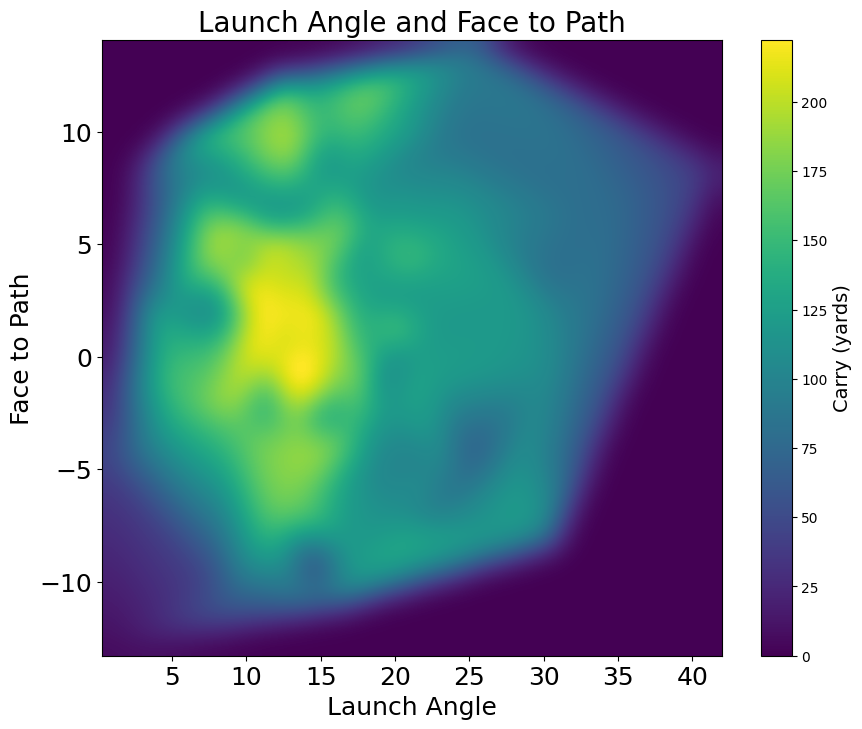

In [8]:
feature_list = df.columns.tolist()
features = feature_list[1:-1]

create_heatmap(df['Launch Angle'], df['Face to Path'], df['Carry'], 'Launch Angle', 'Face to Path', f'Launch Angle and Face to Path')

# for x_feature in features:
#     for y_feature in features:
#      if x_feature != y_feature:
#         create_heatmap(df[x_feature], df[y_feature], df['Carry'], x_feature, y_feature, f'{x_feature} and {y_feature}')

### Clustering

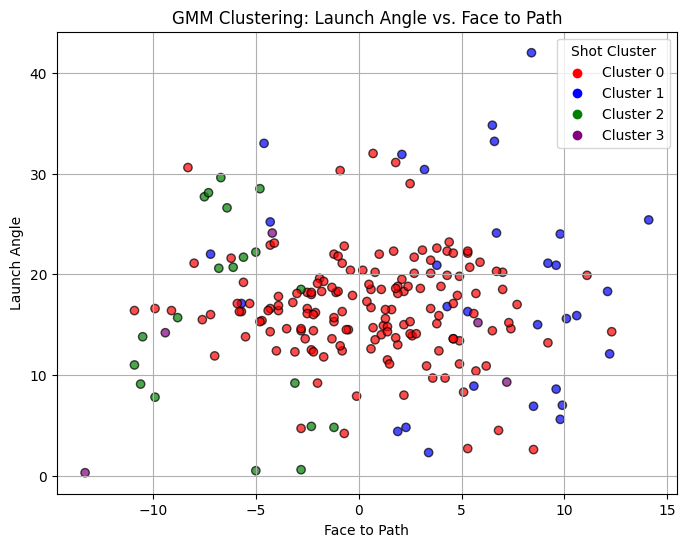

In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('GGXY.csv')

# Select and clean relevant features
features = ["Face Angle", "Face to Path", "Club Path", "Launch Direction", "Launch Angle"]
df_clean = df[features].replace("-", np.nan).dropna().astype(float)

# Standardize for GMM clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean.drop(columns=["Launch Angle"]))  # exclude Launch Angle from clustering

# Fit Gaussian Mixture Model
gmm = GaussianMixture(n_components=4, random_state=42)
df_clean["GMM_Cluster"] = gmm.fit_predict(X_scaled).astype(str)

# Plot: Launch Angle vs. Face to Path
x_feature = "Face to Path"
y_feature = "Launch Angle"
cluster_colors = {"0": "red", "1": "blue", "2": "green", "3": "purple"}
colors = df_clean["GMM_Cluster"].map(cluster_colors)

plt.figure(figsize=(8, 6))
plt.scatter(df_clean[x_feature], df_clean[y_feature], c=colors, alpha=0.7, edgecolors='k')
plt.xlabel(x_feature)
plt.ylabel(y_feature)
plt.title("GMM Clustering: Launch Angle vs. Face to Path")

# Custom legend
for label, color in cluster_colors.items():
    plt.scatter([], [], c=color, label=f"Cluster {label}")
plt.legend(title="Shot Cluster")
plt.grid(True)
plt.show()


In [13]:
# Assuming 'df_clean' is your DataFrame with GMM cluster labels
cluster_means = df_clean.groupby('GMM_Cluster')[['Club Path', 'Face Angle', 'Face to Path']].mean()
print(cluster_means)


             Club Path  Face Angle  Face to Path
GMM_Cluster                                     
0            -3.838462   -3.300000      0.538462
1            -3.346667    2.403333      5.750000
2             0.855000   -5.350000     -6.205000
3            -2.000000   -4.780000     -2.780000


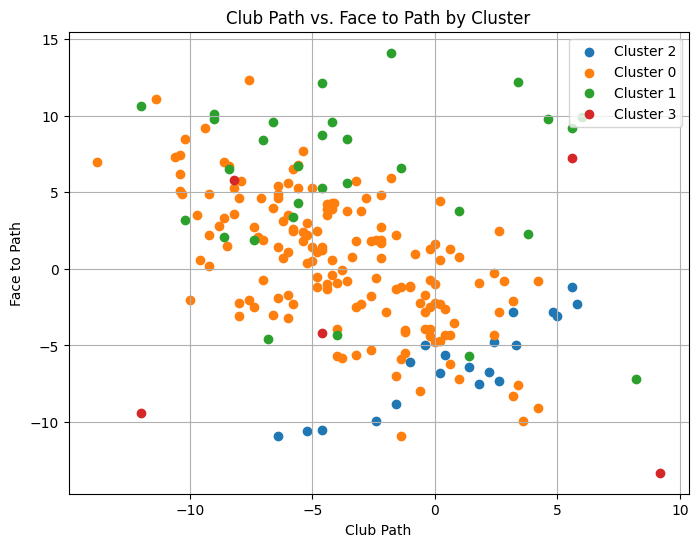

In [14]:
import matplotlib.pyplot as plt

# Scatter plot of Face to Path vs. Club Path
plt.figure(figsize=(8, 6))
for cluster in df_clean['GMM_Cluster'].unique():
    subset = df_clean[df_clean['GMM_Cluster'] == cluster]
    plt.scatter(subset['Club Path'], subset['Face to Path'], label=f'Cluster {cluster}')
plt.xlabel('Club Path')
plt.ylabel('Face to Path')
plt.title('Club Path vs. Face to Path by Cluster')
plt.legend()
plt.grid(True)
plt.show()
